# 05 — Team Drafting Ability
**Finding Hidden Gems: 25 Years of WNBA Draft Value and Player Success**

Which organizations consistently draft steals, avoid busts, and maximize the value of
their draft capital? This notebook rolls the pick-level Draft Steal Score (Notebook 04)
up to the **franchise** level.

We evaluate by `franchise` (relocation-adjusted lineage from Notebook 01), not `team`
(name-at-the-time) — so the Detroit Shock / Tulsa Shock / Dallas Wings front office is
judged as one continuous drafting operation, not three unrelated small samples.

Consistent with Notebook 04, the 2021-2022 draft classes are excluded from every
career-value metric below (too little time to accumulate value), though they still count
toward each franchise's total pick count for context.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLOR_MAIN = '#E56020'
COLOR_ALT  = '#1B3A5C'
COLOR_GREY = '#9AA5B1'
COLOR_BUST = '#B23A48'

clean = pd.read_csv('../data/wnba_draft_clean.csv')
steals = pd.read_csv('../data/draft_steal_scores.csv')

steals['games_ev'] = clean['games'].fillna(0)
steals['is_steal'] = steals['steal_score'] > 0
steals['is_bust']  = steals['steal_score'] < 0

judgeable = steals[~steals['too_early_to_judge']].copy()
print(f"{len(steals)} total picks, {len(judgeable)} judgeable (excludes 2021-2022 classes)")


1064 total picks, 992 judgeable (excludes 2021-2022 classes)


## Franchise draft scorecard

In [2]:
scorecard = judgeable.groupby('franchise').agg(
    picks_judged=('player', 'count'),
    avg_win_shares=('win_shares_ev', 'mean'),
    avg_career_games=('games_ev', 'mean'),
    avg_steal_score=('steal_score', 'mean'),
    steal_rate=('is_steal', 'mean'),
    bust_rate=('is_bust', 'mean'),
    total_win_shares=('win_shares_ev', 'sum'),
    total_expected_win_shares=('expected_win_shares', 'sum'),
)

# Return on Draft Capital: value actually produced vs. value the draft slots implied.
# > 1.0 means the franchise got more out of its picks than an average GM would have;
# < 1.0 means it got less.
scorecard['draft_roi'] = scorecard['total_win_shares'] / scorecard['total_expected_win_shares']

# Total picks including the too-early-to-judge ones, for context in the table
total_picks = steals.groupby('franchise').size().rename('total_picks_alltime')
scorecard = scorecard.join(total_picks)

scorecard = scorecard.sort_values('avg_steal_score', ascending=False)
scorecard.round(3)


,picks_judged,avg_win_shares,avg_career_games,avg_steal_score,steal_rate,bust_rate,total_win_shares,total_expected_win_shares,draft_roi,total_picks_alltime
franchise,,,,,,,,,,
Connecticut Sun,69,5.522,88.391,2.878,0.333,0.667,381.0,182.444,2.088,75
Cleveland Rockers,27,5.722,90.556,2.706,0.333,0.667,154.5,81.433,1.897,27
Charlotte Sting,36,6.103,123.028,2.691,0.528,0.472,219.7,122.826,1.789,36
Sacramento Monarchs,42,5.093,97.429,2.642,0.429,0.571,213.9,102.944,2.078,42
Houston Comets,41,4.169,78.548,2.631,0.500,0.500,175.1,64.590,2.711,42
Chicago Sky,44,7.334,98.932,2.358,0.273,0.727,322.7,218.940,1.474,46
Phoenix Mercury,80,4.676,80.525,2.295,0.412,0.588,374.1,190.532,1.963,83
Seattle Storm,57,5.495,87.123,2.176,0.333,0.667,313.2,189.146,1.656,65
Los Angeles Sparks,76,3.893,64.184,1.749,0.368,0.632,295.9,162.986,1.815,85


## Ranked: best and worst drafting franchises

Ranked by average steal score per pick — the cleanest per-pick measure of "did this front
office beat the market at every slot they picked from." Franchises with fewer than 20
judgeable picks (the three short-lived early-2000s teams) are flagged since a couple of
lucky/unlucky picks swing their average a lot more than it would for a 25-year franchise.


In [3]:
SMALL_SAMPLE_THRESHOLD = 20
ranked = scorecard.copy()
ranked['small_sample'] = ranked['picks_judged'] < SMALL_SAMPLE_THRESHOLD

display_cols = ['picks_judged', 'avg_steal_score', 'steal_rate', 'bust_rate', 'draft_roi', 'small_sample']
print("Best drafting franchises (by average steal score per pick):")
print(ranked[display_cols].head(8).round(3).to_string())
print()
print("Worst drafting franchises (by average steal score per pick):")
print(ranked[display_cols].tail(8).round(3).to_string())


Best drafting franchises (by average steal score per pick):
                     picks_judged  avg_steal_score  steal_rate  bust_rate  draft_roi  small_sample
franchise                                                                                         
Connecticut Sun                69            2.878       0.333      0.667      2.088         False
Cleveland Rockers              27            2.706       0.333      0.667      1.897         False
Charlotte Sting                36            2.691       0.528      0.472      1.789         False
Sacramento Monarchs            42            2.642       0.429      0.571      2.078         False
Houston Comets                 41            2.631       0.500      0.500      2.711         False
Chicago Sky                    44            2.358       0.273      0.727      1.474         False
Phoenix Mercury                80            2.295       0.412      0.588      1.963         False
Seattle Storm                  57            2.17

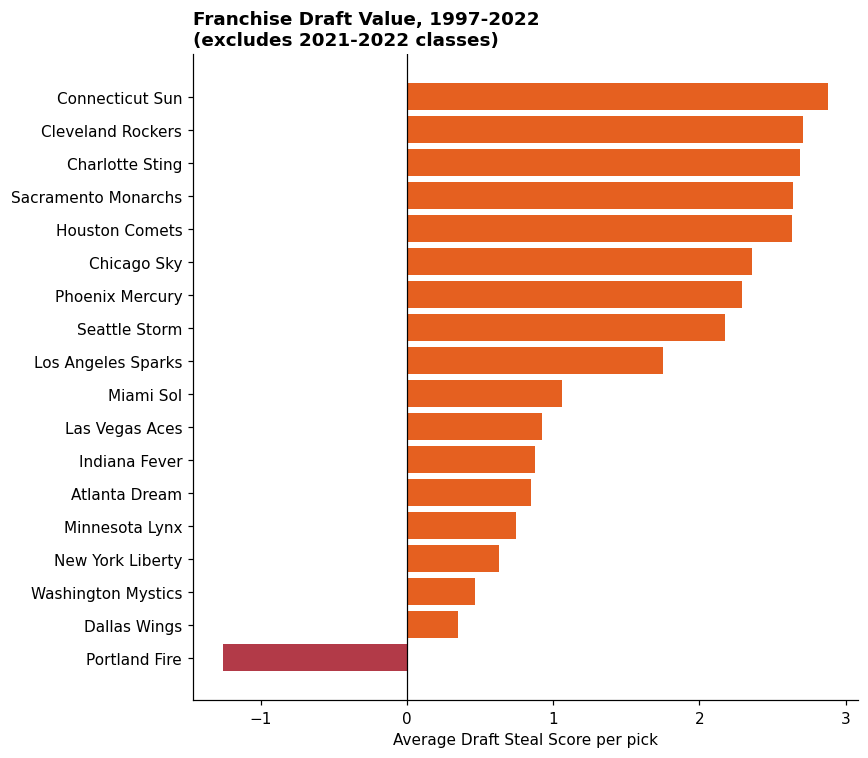

In [4]:
fig, ax = plt.subplots(figsize=(8, 7))
plot_data = scorecard.sort_values('avg_steal_score')
colors = np.where(plot_data['avg_steal_score'] >= 0, COLOR_MAIN, COLOR_BUST)
ax.barh(plot_data.index, plot_data['avg_steal_score'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Average Draft Steal Score per pick')
ax.set_title('Franchise Draft Value, 1997-2022\n(excludes 2021-2022 classes)', loc='left', fontweight='bold')
plt.tight_layout()
plt.savefig('../dashboard/chart_franchise_steal_score.png', dpi=150, bbox_inches='tight')
plt.show()


## Return on Draft Capital

A franchise can have a mediocre *average* steal score but still generate strong total value if it simply drafted well in a couple of key years (or vice versa). ROI captures aggregate efficiency: total value produced per unit of value the draft slots implied.

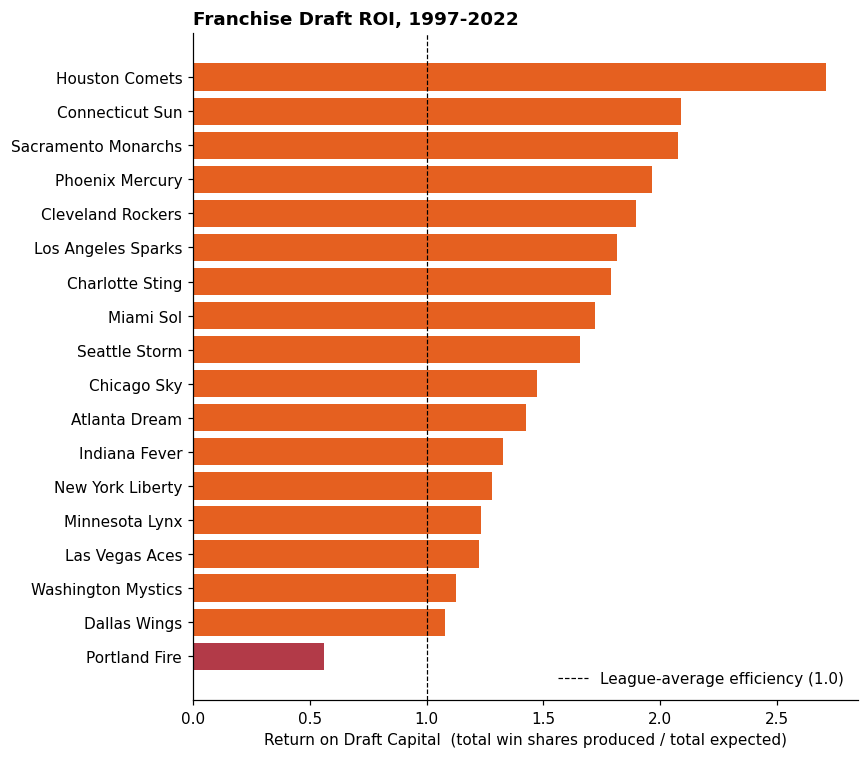

In [5]:
fig, ax = plt.subplots(figsize=(8, 7))
plot_data = scorecard.sort_values('draft_roi')
colors = np.where(plot_data['draft_roi'] >= 1, COLOR_MAIN, COLOR_BUST)
ax.barh(plot_data.index, plot_data['draft_roi'], color=colors)
ax.axvline(1.0, color='black', linewidth=0.8, linestyle='--', label='League-average efficiency (1.0)')
ax.set_xlabel('Return on Draft Capital  (total win shares produced / total expected)')
ax.set_title('Franchise Draft ROI, 1997-2022', loc='left', fontweight='bold')
ax.legend(frameon=False, loc='lower right')
plt.tight_layout()
plt.savefig('../dashboard/chart_franchise_roi.png', dpi=150, bbox_inches='tight')
plt.show()


## Steal rate vs. bust rate

A franchise's *rate* of finding steals vs. producing busts, independent of magnitude — a different lens than the average score above, since one huge hit or miss can dominate an average.

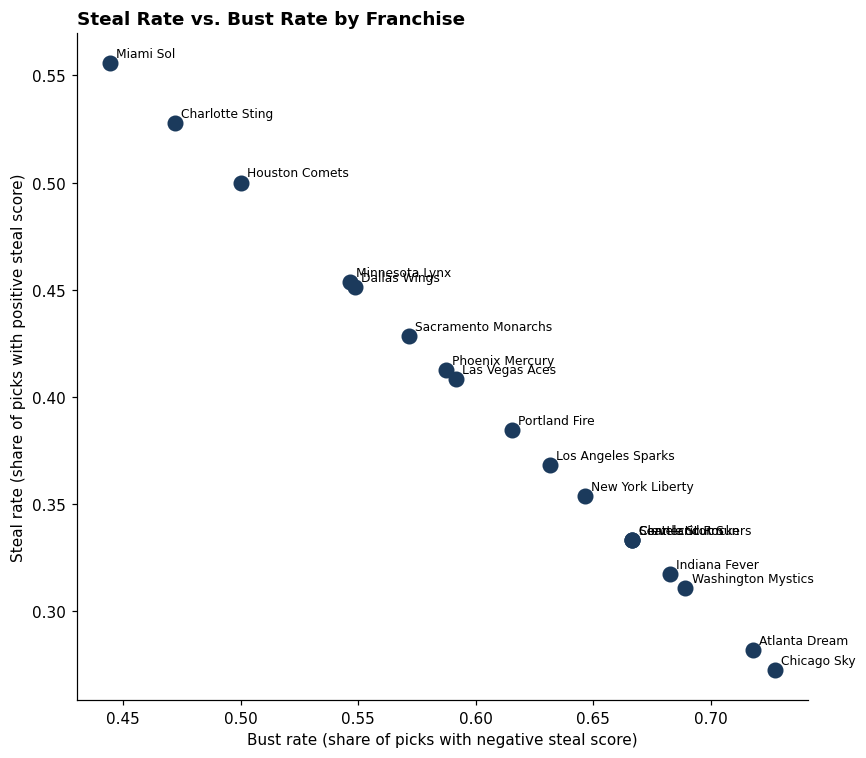

In [6]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(scorecard['bust_rate'], scorecard['steal_rate'], s=90, color=COLOR_ALT, zorder=3)
for name, row in scorecard.iterrows():
    ax.annotate(name, (row['bust_rate'], row['steal_rate']), fontsize=8,
                xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Bust rate (share of picks with negative steal score)')
ax.set_ylabel('Steal rate (share of picks with positive steal score)')
ax.set_title('Steal Rate vs. Bust Rate by Franchise', loc='left', fontweight='bold')
plt.tight_layout()
plt.savefig('../dashboard/chart_franchise_steal_vs_bust_rate.png', dpi=150, bbox_inches='tight')
plt.show()


## Save the franchise scorecard

In [7]:
scorecard.reset_index().to_csv('../data/franchise_draft_scorecard.csv', index=False)
print(f"Saved data/franchise_draft_scorecard.csv - {len(scorecard)} franchises")


Saved data/franchise_draft_scorecard.csv - 18 franchises
